Epoch [0/2000], Loss: 5031.731445
Epoch [200/2000], Loss: 2016.602905
Epoch [400/2000], Loss: 216.086548
Epoch [600/2000], Loss: 187.892593
Epoch [800/2000], Loss: 181.083130
Epoch [1000/2000], Loss: 176.488770
Epoch [1200/2000], Loss: 173.791092
Epoch [1400/2000], Loss: 172.414383
Epoch [1600/2000], Loss: 171.806946
Epoch [1800/2000], Loss: 171.577011
Test Loss: 1350.195801


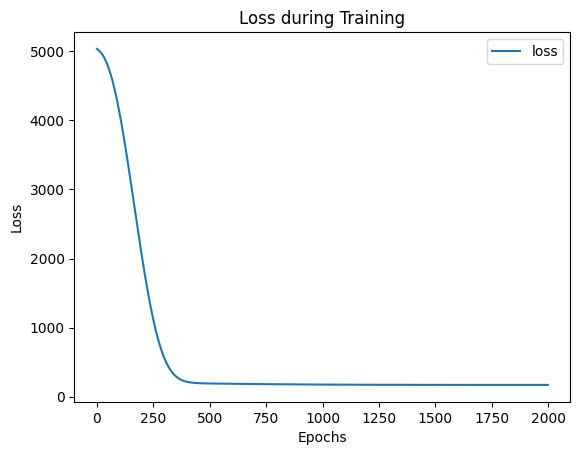

Prediction: 51.02418899536133


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load Dataset
dataset1 = pd.read_csv('C:\\Users\\admin\\Desktop\\DEEPLEARNING\\DEEPLEARNING - Sheet1.csv')

X = dataset1[['Input']].values
y = dataset1[['Output']].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=33
)

# Feature Scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(1, 10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )
        
        self.history = {'loss': []}

    def forward(self, x):
        return self.model(x)


ai_brain = NeuralNet()

criterion = nn.MSELoss()
optimizer = optim.Adam(ai_brain.parameters(), lr=0.01)


def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    
    for epoch in range(epochs):
        
       
        outputs = ai_brain(X_train)
        loss = criterion(outputs, y_train)
        

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    
        ai_brain.history['loss'].append(loss.item())
        
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')


train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)


with torch.no_grad():
    test_loss = criterion(ai_brain(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


loss_df = pd.DataFrame(ai_brain.history)

loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()


X_n1_1 = torch.tensor([[9]], dtype=torch.float32)

prediction = ai_brain(
    torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)
).item()

print(f'Prediction: {prediction}')